# Research Paper Categorization
---

## Pipeline Overview

Our journey:
1. **Load & explore** the data
2. **Preprocess** text (clean, normalize, tokenize)
3. **Vectorize** with TF-IDF (text → numbers)
4. **Build a classifier from scratch** (multinomial logistic regression)
5. **Train** with gradient descent
6. **Evaluate** thoroughly (confusion matrix, metrics, confidence, misclassifications)
7. **Demo** on a new paper


In [49]:
import re
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
sns.set_theme(style='whitegrid')


## Load Dataset and Inspect Structure

Required columns:
- label: class name
- title: paper title
- abstract: paper abstract


In [50]:
df = pd.read_csv('data/combined_papers_cleaned.csv')
use_cols = ['label', 'title', 'abstract']
df = df[use_cols].dropna().copy()
print('Shape:', df.shape)
display(df.head())


Shape: (2855, 3)


,label,title,abstract
0,APPLIED,Towards Generalizable Robotic Manipulation in ...,Vision-Language-Action (VLA) models excel in s...
1,APPLIED,Mixture-of-Depths Attention,Scaling depth is a key driver for large langua...
2,APPLIED,Look Before Acting: Enhancing Vision Foundatio...,Vision-Language-Action (VLA) models have recen...
3,APPLIED,HorizonMath: Measuring AI Progress Toward Math...,"Can AI make progress on important, unsolved ma..."
4,APPLIED,GlyphPrinter: Region-Grouped Direct Preference...,Generating accurate glyphs for visual text ren...


In [51]:
sample_table = (
    df[['label', 'title']]
    .groupby('label', as_index=False)
    .head(1)
    .rename(columns={'label': 'category'})
)
display(sample_table)


,category,title
0,APPLIED,Towards Generalizable Robotic Manipulation in ...
998,THEORETICAL,Smaller Depth-2 Linear Circuits for Disjointne...
1996,SURVEY,A Comprehensive Survey on Community Detection ...


## Class Distribution Visualization

Check imbalance before modeling.


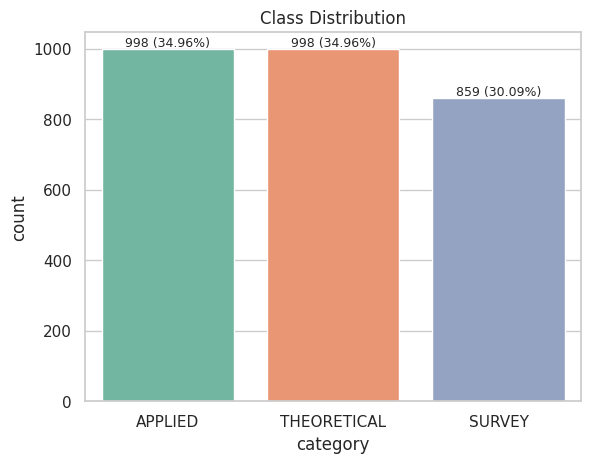

In [52]:
counts = df['label'].value_counts()
perc = (counts / counts.sum() * 100).round(2)
plot_df = pd.DataFrame({'category': counts.index, 'count': counts.values, 'pct': perc.values})

a = sns.barplot(data=plot_df, x='category', y='count', hue='category', palette='Set2', legend=False)
for i, r in plot_df.reset_index(drop=True).iterrows():
    a.text(i, r['count'], f"{int(r['count'])} ({r['pct']}%)", ha='center', va='bottom', fontsize=9)
plt.title('Class Distribution')
plt.show()


## Step-by-Step Text Preprocessing Pipeline

We show one abstract through: raw -> lower -> stopword-removed -> stemmed.

This section is both a conceptual illustration and the actual preprocessing used for modeling.
We apply tokenization, stopword removal, and proper stemming (Porter stemmer) before TF-IDF.

In [53]:
stop_words = set(ENGLISH_STOP_WORDS)
stemmer = PorterStemmer()

def tokens(t):
    return re.findall(r'[a-z]+', str(t).lower())

def preprocess_text(t):
    tok = tokens(t)
    no_stop = [w for w in tok if w not in stop_words]
    stemmed = [stemmer.stem(w) for w in no_stop]
    return ' '.join(stemmed)

raw = df.iloc[0]['abstract']
lower = raw.lower()
no_stop = ' '.join([w for w in tokens(raw) if w not in stop_words])
stemmed = preprocess_text(raw)

display(pd.DataFrame({
    'stage': ['raw', 'lowercased', 'stopwords_removed', 'porter_stemmed'],
    'text': [raw, lower, no_stop, stemmed]
}))


,stage,text
0,raw,Vision-Language-Action (VLA) models excel in s...
1,lowercased,vision-language-action (vla) models excel in s...
2,stopwords_removed,vision language action vla models excel static...
3,porter_stemmed,vision languag action vla model excel static m...


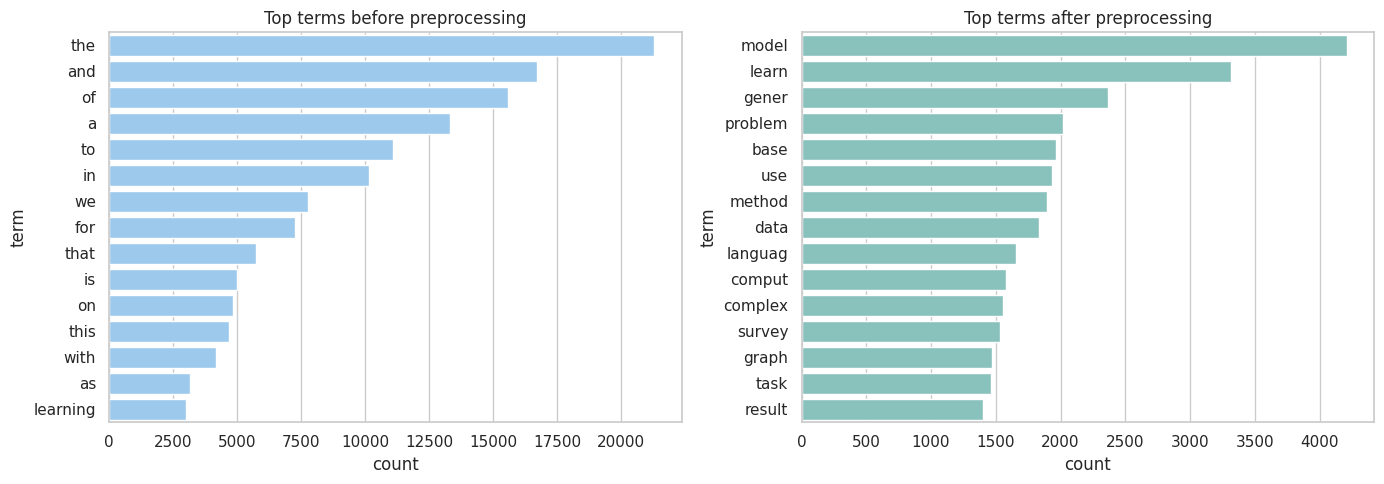

In [54]:
def top_terms(series, n=15):
    c = Counter()
    for t in series:
        c.update(tokens(t))
    return pd.DataFrame(c.most_common(n), columns=['term', 'count'])

before = top_terms(df['title'] + ' ' + df['abstract'])
after = top_terms((df['title'] + ' ' + df['abstract']).map(preprocess_text))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=before, x='count', y='term', ax=ax[0], color='#90caf9')
ax[0].set_title('Top terms before preprocessing')
sns.barplot(data=after, x='count', y='term', ax=ax[1], color='#80cbc4')
ax[1].set_title('Top terms after preprocessing')
plt.tight_layout(); plt.show()


## Combine Title and Abstract into One Preprocessed Feature

Title is short and high-signal; abstract adds context.
We first combine them, then apply the preprocessing pipeline so the model learns from normalized text.


In [55]:
pd.set_option('display.max_colwidth', None)
df[['title', 'abstract']].iloc[0:1].T

,0
title,Towards Generalizable Robotic Manipulation in Dynamic Environments
abstract,"Vision-Language-Action (VLA) models excel in static manipulation but struggle in dynamic environments with moving targets. This performance gap primarily stems from a scarcity of dynamic manipulation datasets and the reliance of mainstream VLAs on single-frame observations, restricting their spatiotemporal reasoning capabilities. To address this, we introduce DOMINO, a large-scale dataset and benchmark for generalizable dynamic manipulation, featuring 35 tasks with hierarchical complexities, over 110K expert trajectories, and a multi-dimensional evaluation suite. Through comprehensive experiments, we systematically evaluate existing VLAs on dynamic tasks, explore effective training strategies for dynamic awareness, and validate the generalizability of dynamic data. Furthermore, we propose PUMA, a dynamics-aware VLA architecture. By integrating scene-centric historical optical flow and specialized world queries to implicitly forecast object-centric future states, PUMA couples history-aware perception with short-horizon prediction. Results demonstrate that PUMA achieves state-of-the-art performance, yielding a 6.3% absolute improvement in success rate over baselines. Moreover, we show that training on dynamic data fosters robust spatiotemporal representations that transfer to static tasks. All code and data are available at https://github.com/H-EmbodVis/DOMINO."


In [56]:
df['combined_text_raw'] = (df['title'].fillna('') + ' ' + df['abstract'].fillna('')).str.strip()
df['combined_text'] = df['combined_text_raw'].map(preprocess_text)

display(df[['combined_text_raw', 'combined_text']].head(1))


,combined_text_raw,combined_text
0,"Towards Generalizable Robotic Manipulation in Dynamic Environments Vision-Language-Action (VLA) models excel in static manipulation but struggle in dynamic environments with moving targets. This performance gap primarily stems from a scarcity of dynamic manipulation datasets and the reliance of mainstream VLAs on single-frame observations, restricting their spatiotemporal reasoning capabilities. To address this, we introduce DOMINO, a large-scale dataset and benchmark for generalizable dynamic manipulation, featuring 35 tasks with hierarchical complexities, over 110K expert trajectories, and a multi-dimensional evaluation suite. Through comprehensive experiments, we systematically evaluate existing VLAs on dynamic tasks, explore effective training strategies for dynamic awareness, and validate the generalizability of dynamic data. Furthermore, we propose PUMA, a dynamics-aware VLA architecture. By integrating scene-centric historical optical flow and specialized world queries to implicitly forecast object-centric future states, PUMA couples history-aware perception with short-horizon prediction. Results demonstrate that PUMA achieves state-of-the-art performance, yielding a 6.3% absolute improvement in success rate over baselines. Moreover, we show that training on dynamic data fosters robust spatiotemporal representations that transfer to static tasks. All code and data are available at https://github.com/H-EmbodVis/DOMINO.",generaliz robot manipul dynam environ vision languag action vla model excel static manipul struggl dynam environ move target perform gap primarili stem scarciti dynam manipul dataset relianc mainstream vla singl frame observ restrict spatiotempor reason capabl address introduc domino larg scale dataset benchmark generaliz dynam manipul featur task hierarch complex k expert trajectori multi dimension evalu suit comprehens experi systemat evalu exist vla dynam task explor effect train strategi dynam awar valid generaliz dynam data furthermor propos puma dynam awar vla architectur integr scene centric histor optic flow special world queri implicitli forecast object centric futur state puma coupl histori awar percept short horizon predict result demonstr puma achiev state art perform yield absolut improv success rate baselin train dynam data foster robust spatiotempor represent transfer static task code data avail http github com h embodvi domino


In [57]:
pd.reset_option('display.max_colwidth')

## TF, IDF, and TF-IDF Intuition with Toy Sentences

Formulas:

$$TF(t,d)=\frac{f_{t,d}}{\sum_j f_{j,d}}$$
$$IDF(t)=\log\left(\frac{N}{1+df(t)}\right)+1$$
$$TFIDF(t,d)=TF(t,d)\cdot IDF(t)$$


In [58]:
toy_docs = [
    'graph neural networks for molecules',
    'neural networks for image classification',
    'bayesian inference for scientific models'
]
toy_vec = TfidfVectorizer()
toy_X = toy_vec.fit_transform(toy_docs)
display(pd.DataFrame(toy_X.toarray(), columns=toy_vec.get_feature_names_out()))


,bayesian,classification,for,graph,image,inference,models,molecules,networks,neural,scientific
0,0.000000,0.000000,0.315444,0.534093,0.000000,0.000000,0.000000,0.534093,0.406192,0.406192,0.000000
1,0.000000,0.534093,0.315444,0.000000,0.534093,0.000000,0.000000,0.000000,0.406192,0.406192,0.000000
2,0.479528,0.000000,0.283217,0.000000,0.000000,0.479528,0.479528,0.000000,0.000000,0.000000,0.479528


## Train/Validation/Test Split and Fit TF-IDF (No Leakage)

Split text first, then fit TF-IDF only on the training subset.

Preprocessing used for this modeling step:
- `combined_text` is title + abstract after tokenization, stopword removal, and Porter stemming.
- TF-IDF is then fit on these preprocessed texts using train-only vocabulary.
- This keeps the pipeline consistent while still preventing data leakage.

In [ ]:
# Encode labels first so stratified splits are stable and reproducible.
label_names = sorted(df['label'].unique())
lab2i = {l: i for i, l in enumerate(label_names)}
i2lab = {i: l for l, i in lab2i.items()}

y = np.array([lab2i[x] for x in df['label']])
all_idx = np.arange(len(df))
X_text = df['combined_text'].values

# First split: hold out final test set from raw text.
X_trainval_text, X_test_text, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X_text, y, all_idx, test_size=0.2, random_state=42, stratify=y
)

# Second split: carve validation from train/val pool.
X_train_text, X_val_text, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval_text, y_trainval, idx_trainval,
    test_size=0.2, random_state=42, stratify=y_trainval
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=12000, min_df=3, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)

feature_names = np.array(vectorizer.get_feature_names_out())
dfreq = np.asarray((X_train > 0).sum(axis=0)).ravel()

print('Train TF-IDF shape:', X_train.shape)
print('Validation TF-IDF shape:', X_val.shape)
print('Test TF-IDF shape:', X_test.shape)
print('Vocabulary size (fit on train only):', len(feature_names))

most_idx = np.argsort(-dfreq)[:10]
least_idx = np.argsort(dfreq)[:10]
display(pd.DataFrame({'term': feature_names[most_idx], 'train_doc_freq': dfreq[most_idx]}))
display(pd.DataFrame({'term': feature_names[least_idx], 'train_doc_freq': dfreq[least_idx]}))

Train TF-IDF shape: (1827, 12000)
Validation TF-IDF shape: (457, 12000)
Test TF-IDF shape: (571, 12000)
Vocabulary size (fit on train only): 12000


,term,train_doc_freq
0,model,988
1,use,806
2,base,728
3,gener,721
4,learn,678
5,method,639
6,result,637
7,provid,636
8,problem,602
9,comput,564


,term,train_doc_freq
0,accuraci effici,3
1,accuraci imag,3
2,accuraci work,3
3,work simpl,3
4,work summar,3
5,work survey,3
6,world condit,3
7,world domain,3
8,unleash,3
9,unless np,3


## TF-IDF Matrix Sparsity and Hyperparameter Effects (Train Split)

Train TF-IDF sparsity ratio: 0.9917


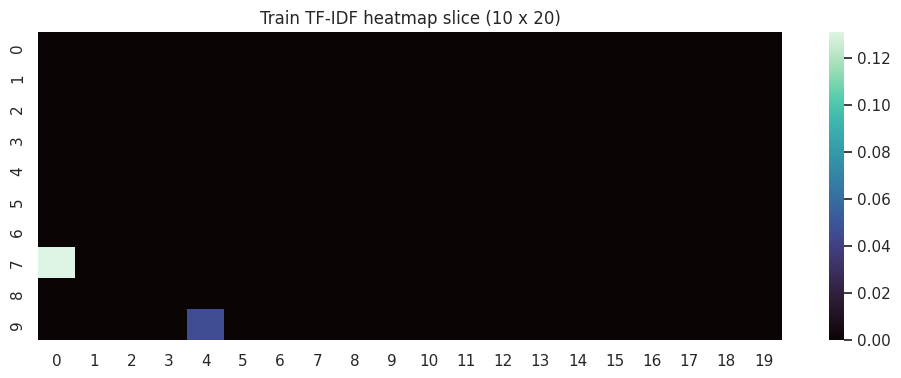

Train unigram vocab size: 3587
Train unigram+bigram vocab size: 12000


In [60]:
sparsity = 1.0 - (X_train.nnz / (X_train.shape[0] * X_train.shape[1]))
print('Train TF-IDF sparsity ratio:', round(sparsity, 4))

slice_mat = X_train[:10, :20].toarray()
plt.figure(figsize=(12, 4))
sns.heatmap(slice_mat, cmap='mako')
plt.title('Train TF-IDF heatmap slice (10 x 20)')
plt.show()

uni = TfidfVectorizer(stop_words='english', max_features=12000, min_df=3, ngram_range=(1,1)).fit(X_train_text)
bi = TfidfVectorizer(stop_words='english', max_features=12000, min_df=3, ngram_range=(1,2)).fit(X_train_text)
print('Train unigram vocab size:', len(uni.get_feature_names_out()))
print('Train unigram+bigram vocab size:', len(bi.get_feature_names_out()))

## Implement Softmax and Cross-Entropy (From Scratch)

Before training, we need two core ideas:

1. **Softmax** turns raw model scores (logits) into probabilities that sum to 1.
2. **Cross-entropy** measures how far those predicted probabilities are from the true class labels.

### What Softmax Does (Plain English)

Our model outputs one score per class for each paper. Those scores are not probabilities yet.
Softmax rescales them so we can interpret each value as "the model's confidence for this class."

$$
\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

After softmax, each class probability is between 0 and 1, and all class probabilities add to 1.

### Why Cross-Entropy Instead of MSE?

For classification, we want the probability of the correct class to be as high as possible.
Cross-entropy directly penalizes confident wrong predictions and rewards confident correct ones.

$$
\mathcal{L}_{CE} = -\frac{1}{N}\sum_{n=1}^{N}\sum_{k=1}^{K} y_{n,k}\log(p_{n,k})
$$

Where $y_{n,k}$ is 1 only for the true class, and $p_{n,k}$ is the predicted probability.

Why not MSE?
- MSE treats classification more like regression and gives weaker learning signals for probabilities.
- Cross-entropy pairs naturally with softmax and gives cleaner gradients for multi-class learning.
- In practice, cross-entropy usually converges faster and to better classifiers.

In [61]:
def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(y_onehot, p, eps=1e-12):
    p = np.clip(p, eps, 1-eps)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))

toy_logits = np.array([[2.0, 1.0, 0.1]])
toy_prob = softmax(toy_logits)
print('Softmax:', toy_prob.round(4), 'sum=', toy_prob.sum().round(4))

y_true = np.array([[1,0,0]])
print('Low loss:', round(cross_entropy(y_true, np.array([[0.9, 0.08, 0.02]])), 4))
print('High loss:', round(cross_entropy(y_true, np.array([[0.05, 0.9, 0.05]])), 4))


Softmax: [[0.659  0.2424 0.0986]] sum= 1.0
Low loss: 0.1054
High loss: 2.9957


## Logistic Regression Training Loop

Split and vectorization are already done above to prevent leakage.

### Cell A: prepare encoded labels/splits for training (created in Cell 16) and build matrices.

In [62]:
Xtr = X_train.toarray()
Xva = X_val.toarray()
Xte = X_test.toarray()

def one_hot(y, k):
    o = np.zeros((len(y), k))
    o[np.arange(len(y)), y] = 1
    return o

k = len(label_names)
Ytr = one_hot(y_train, k)

print('Train shape:', Xtr.shape)
print('Validation shape:', Xva.shape)
print('Test shape:', Xte.shape)
print('Number of classes:', k)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'samples': [len(y_train), len(y_val), len(y_test)],
})
display(split_summary)

Train shape: (1827, 12000)
Validation shape: (457, 12000)
Test shape: (571, 12000)
Number of classes: 3


,split,samples
0,train,1827
1,validation,457
2,test,571


### Cell B: Initialize Model Parameters ($W$ and $b$)

$W$ is the weight matrix.

Each column in $W$ learns which TF-IDF features support one class.
$b$ is a bias vector with one offset per class.

We initialize $W$ with small random values to break symmetry, and $b$ with zeros.

In [63]:
k = len(label_names)
W = 0.01 * np.random.randn(Xtr.shape[1], k)
b = np.zeros((1, k))

print('W shape:', W.shape)
print('b shape:', b.shape)

W shape: (12000, 3)
b shape: (1, 3)


### Cell C: Run Gradient Descent Training

At each epoch we do four steps:

1. Forward pass: compute logits, softmax probabilities, and loss.
2. Backward pass: compute gradients of $W$ and $b$.
3. Parameter update: move parameters opposite the gradient.
4. Monitoring: track loss, train accuracy, and validation accuracy.

In [64]:
train_cfg = {
    'epochs': 300,
    'learning_rate': 0.5,
    'l2': 1e-4,
    'print_every': 20,
}


In [65]:


# Read hyperparameters from the separate control cell.
default_cfg = {'epochs': 100, 'learning_rate': 0.5, 'l2': 1e-4, 'print_every': 20}
if 'train_cfg' not in globals():
    print('train_cfg not found, using defaults.')
cfg = train_cfg if 'train_cfg' in globals() else default_cfg

epochs = int(cfg.get('epochs', default_cfg['epochs']))
lr = float(cfg.get('learning_rate', default_cfg['learning_rate']))
l2 = float(cfg.get('l2', default_cfg['l2']))
print_every = max(1, int(cfg.get('print_every', default_cfg['print_every'])))

hist = {'loss': [], 'train_acc': [], 'val_acc': []}
progress_rows = []

print(f"\nTraining start | epochs={epochs}, lr={lr}, l2={l2}, print_every={print_every}")
for ep in range(epochs):
    logits = Xtr @ W + b
    p = softmax(logits)
    loss = cross_entropy(Ytr, p) + 0.5 * l2 * np.sum(W * W)

    dlog = (p - Ytr) / len(y_train)
    dW = Xtr.T @ dlog + l2 * W
    db = dlog.sum(axis=0, keepdims=True)

    W -= lr * dW
    b -= lr * db

    tr_pred = p.argmax(axis=1)
    val_pred = softmax(Xva @ W + b).argmax(axis=1)

    train_acc = float((tr_pred == y_train).mean())
    val_acc = float((val_pred == y_val).mean())

    hist['loss'].append(float(loss))
    hist['train_acc'].append(train_acc)
    hist['val_acc'].append(val_acc)

    if ep == 0 or (ep + 1) % print_every == 0 or ep == epochs - 1:
        start_epoch = 0 if ep == 0 else max(0, ep + 1 - print_every)
        print(
            f"Epoch {start_epoch}-{ep + 1} | "
            f"loss={loss:.4f} | accuracy={train_acc:.4f} | val={val_acc:.4f}"
        )
        progress_rows.append({
            'epoch_range': f'{start_epoch}-{ep + 1}',
            'loss': float(loss),
            'train_acc': train_acc,
            'val_acc': val_acc,
        })

progress_df = pd.DataFrame(progress_rows)





Training start | epochs=300, lr=0.5, l2=0.0001, print_every=20


Epoch 0-1 | loss=1.0977 | accuracy=0.3673 | val=0.4223
Epoch 0-20 | loss=1.0484 | accuracy=0.6831 | val=0.6937
Epoch 20-40 | loss=1.0020 | accuracy=0.8155 | val=0.8184
Epoch 40-60 | loss=0.9589 | accuracy=0.8993 | val=0.8928
Epoch 60-80 | loss=0.9186 | accuracy=0.9272 | val=0.9147
Epoch 80-100 | loss=0.8812 | accuracy=0.9392 | val=0.9300
Epoch 100-120 | loss=0.8463 | accuracy=0.9475 | val=0.9409
Epoch 120-140 | loss=0.8138 | accuracy=0.9513 | val=0.9497
Epoch 140-160 | loss=0.7835 | accuracy=0.9562 | val=0.9562
Epoch 160-180 | loss=0.7553 | accuracy=0.9579 | val=0.9584
Epoch 180-200 | loss=0.7290 | accuracy=0.9584 | val=0.9562
Epoch 200-220 | loss=0.7045 | accuracy=0.9611 | val=0.9628
Epoch 220-240 | loss=0.6816 | accuracy=0.9617 | val=0.9628
Epoch 240-260 | loss=0.6601 | accuracy=0.9622 | val=0.9628
Epoch 260-280 | loss=0.6400 | accuracy=0.9628 | val=0.9650
Epoch 280-300 | loss=0.6212 | accuracy=0.9628 | val=0.9650


## Track Training Curves (Loss, Train Accuracy, Validation Accuracy)


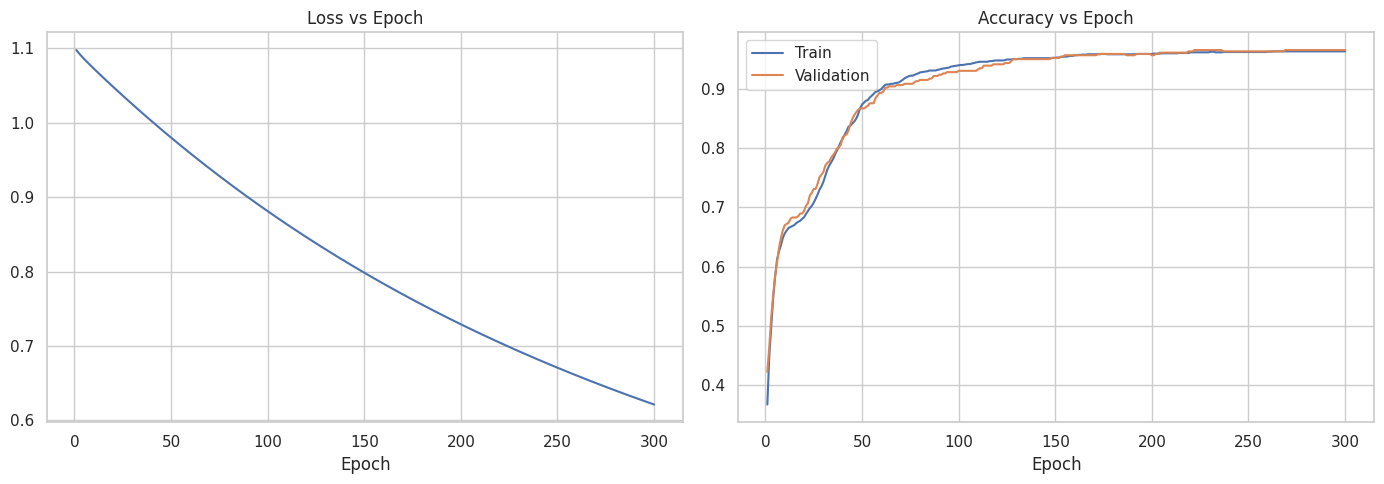

In [66]:
e = np.arange(1, len(hist['loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(e, hist['loss'])
ax[0].set_title('Loss vs Epoch')
ax[0].set_xlabel('Epoch')

ax[1].plot(e, hist['train_acc'], label='Train')
ax[1].plot(e, hist['val_acc'], label='Validation')
ax[1].set_title('Accuracy vs Epoch')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

## Inspect Top Weighted Terms per Class


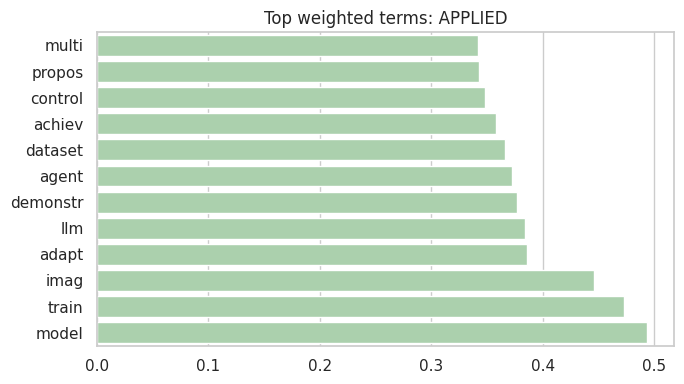

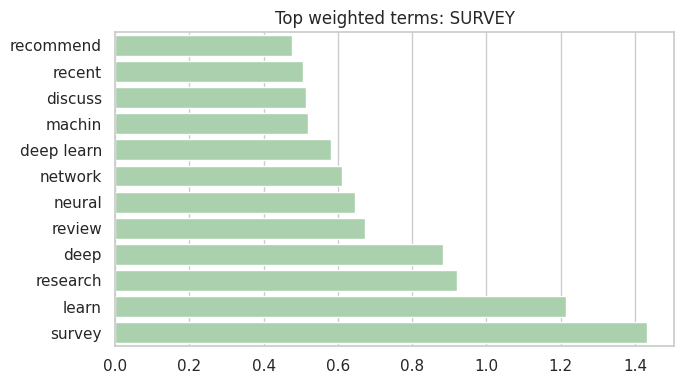

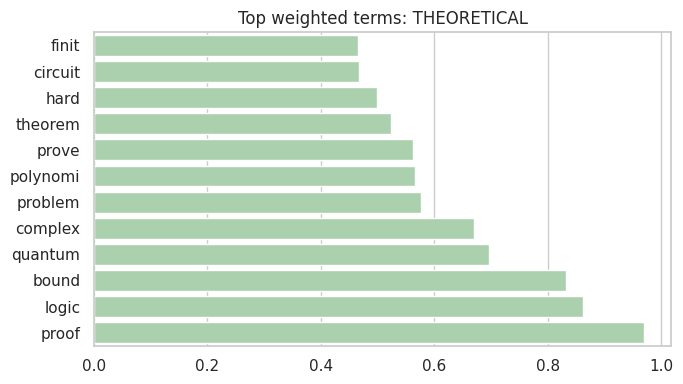

In [67]:
fn = np.array(vectorizer.get_feature_names_out())
for cidx, cname in i2lab.items():
    top = np.argsort(W[:, cidx])[-12:]
    terms = fn[top]
    vals = W[top, cidx]
    plt.figure(figsize=(7,4))
    sns.barplot(x=vals, y=terms, orient='h', color='#a5d6a7')
    plt.title(f'Top weighted terms: {cname}')
    plt.tight_layout(); plt.show()


## Final Test-Set Evaluation Metrics

These metrics are computed only once after training completes.


Overall accuracy: 0.9597


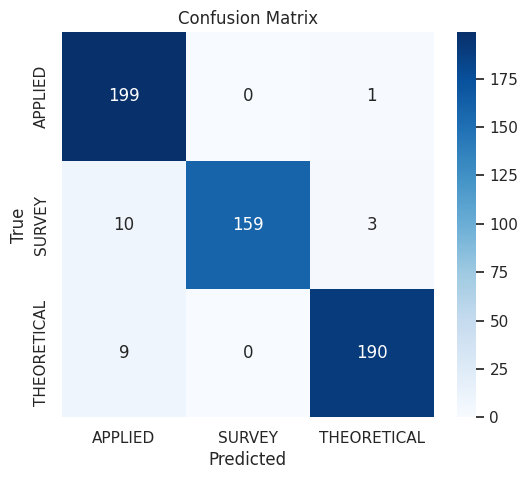

,precision,recall,f1-score
APPLIED,0.912844,0.995000,0.952153
SURVEY,1.000000,0.924419,0.960725
THEORETICAL,0.979381,0.954774,0.966921
accuracy,0.959720,0.959720,0.959720
macro avg,0.964075,0.958064,0.959933
weighted avg,0.962287,0.959720,0.959882


In [68]:
probs = softmax(Xte @ W + b)
y_pred = probs.argmax(axis=1)
acc = accuracy_score(y_test, y_pred)
print('Overall accuracy:', round(acc, 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

rep = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
rep_df = pd.DataFrame(rep).T
if 'support' in rep_df.columns:
    rep_df = rep_df.drop(columns=['support'])
display(rep_df)


## Confidence Distribution and Calibration Check


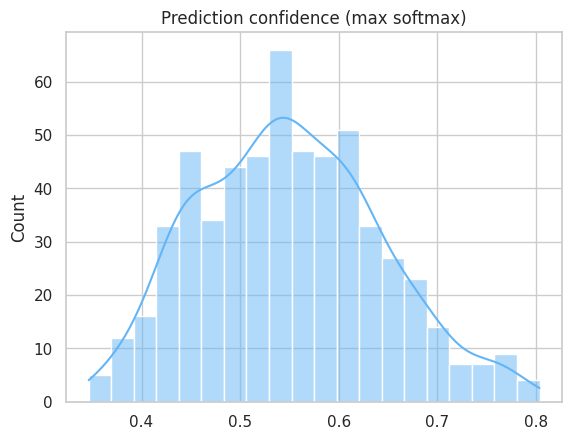

/tmp/ipykernel_177507/1363260664.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(grp.groupby('bucket').agg(count=('correct','size'), accuracy=('correct','mean')).reset_index())


,bucket,count,accuracy
0,"(-0.001, 0.4]",20,0.500000
1,"(0.4, 0.6]",379,0.965699
2,"(0.6, 0.8]",171,1.000000
3,"(0.8, 1.0]",1,1.000000


In [69]:
conf = probs.max(axis=1)
correct = (y_pred == y_test).astype(int)

sns.histplot(conf, bins=20, kde=True, color='#64b5f6')
plt.title('Prediction confidence (max softmax)')
plt.show()

grp = pd.DataFrame({'confidence': conf, 'correct': correct})
grp['bucket'] = pd.cut(grp['confidence'], bins=[0,0.4,0.6,0.8,1.0], include_lowest=True)
display(grp.groupby('bucket').agg(count=('correct','size'), accuracy=('correct','mean')).reset_index())


## Misclassification Review with Real Examples


In [70]:
err = np.where(y_pred != y_test)[0][:]
rows = []
for i in err:
    gi = idx_test[i]
    rows.append({
        'title': df.iloc[gi]['title'],
        'true_label': i2lab[y_test[i]],
        'pred_label': i2lab[y_pred[i]],
        'confidence': round(float(conf[i]), 4),
        'abstract_snippet': df.iloc[gi]['abstract'][:350] + '...'
    })
display(pd.DataFrame(rows))


,title,true_label,pred_label,confidence,abstract_snippet
0,Unsupervised Hierarchical Skill Discovery,THEORETICAL,APPLIED,0.4524,We consider the problem of unsupervised skill ...
1,Prediction of neonatal mortality in Sub-Sahara...,SURVEY,APPLIED,0.3945,Existing datasets available to address crucial...
2,Diffusion Models for Medical Image Analysis: A...,SURVEY,APPLIED,0.4748,"Denoising diffusion models, a class of generat..."
3,Diffusion Models in Vision: A Survey,SURVEY,APPLIED,0.4502,Denoising diffusion models represent a recent ...
4,A Survey on Visual Map Localization Using LiDA...,SURVEY,APPLIED,0.4590,As the autonomous driving industry is slowly m...
5,Differentiable Logic Synthesis: Spectral Coeff...,THEORETICAL,APPLIED,0.4238,Learning precise Boolean logic via gradient de...
6,"Formal that ""Floats"" High: Formal Verification...",THEORETICAL,APPLIED,0.4140,Formal verification of floating-point arithmet...
7,Eight Things to Know about Large Language Models,SURVEY,APPLIED,0.4528,The widespread public deployment of large lang...
8,An Introduction to Autoencoders,SURVEY,THEORETICAL,0.3464,"In this article, we will look at autoencoders...."
9,Beyond Correctness: Exposing LLM-generated Log...,THEORETICAL,APPLIED,0.4416,Large Language Models (LLMs) have demonstrated...


## Conclusion

Our model classifies unseen papers from title + abstract with meaningful accuracy and interpretable term weights.

Potential improvements:
- richer preprocessing and phrase features
- more labeled data
- transformer-based text encoders


## Save Trained Artifacts for Future Use

Store all required objects so you can load the model later and run inference without retraining.

In [71]:
save_dir = Path('models/tfidf_scratch')
save_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    'vectorizer': vectorizer,
    'weights': W,
    'bias': b,
    'label_names': label_names,
    'label_to_index': lab2i,
    'index_to_label': i2lab,
    'preprocess_fn_name': 'preprocess_text',
}

save_path = save_dir / 'scratch_logreg_artifacts.joblib'
joblib.dump(artifact, save_path)
print('Saved:', save_path)

# Optional check: load back from disk for future session reuse.
loaded_artifact = joblib.load(save_path)
print('Loaded keys:', sorted(loaded_artifact.keys()))

Saved: models/tfidf_scratch/scratch_logreg_artifacts.joblib
Loaded keys: ['bias', 'index_to_label', 'label_names', 'label_to_index', 'preprocess_fn_name', 'vectorizer', 'weights']


## Interactive Prediction Cell

Paste a new title + abstract below and get predicted class + confidence.


In [72]:
# Predict using only saved artifacts (no retraining needed in this session).
artifact_path = Path('models/tfidf_scratch/scratch_logreg_artifacts.joblib')
loaded_artifact = joblib.load(artifact_path)

vectorizer_loaded = loaded_artifact['vectorizer']
W_loaded = loaded_artifact['weights']
b_loaded = loaded_artifact['bias']
i2lab_loaded = loaded_artifact['index_to_label']
label_names_loaded = loaded_artifact['label_names']

new_title = 'A Survey of Efficient Transformer Compression Methods'
new_abstract = 'This survey reviews pruning, quantization, distillation, and low-rank adaptation methods for compressing large transformer models while preserving downstream performance.'

new_text_raw = (new_title + ' ' + new_abstract).strip()
new_text_processed = preprocess_text(new_text_raw)
new_x = vectorizer_loaded.transform([new_text_processed]).toarray()
new_prob = softmax(new_x @ W_loaded + b_loaded)[0]
new_idx = int(np.argmax(new_prob))

print('Loaded artifact from:', artifact_path)
print('Predicted category:', i2lab_loaded[new_idx])
print('Confidence:', round(float(new_prob[new_idx]), 4))

display(
    pd.DataFrame({
        'class': [i2lab_loaded[i] for i in range(len(label_names_loaded))],
        'probability': new_prob
    }).sort_values('probability', ascending=False)
)


Loaded artifact from: models/tfidf_scratch/scratch_logreg_artifacts.joblib
Predicted category: APPLIED
Confidence: 0.3779


,class,probability
0,APPLIED,0.377901
1,SURVEY,0.370780
2,THEORETICAL,0.251319
